# Notebook 2: Visual Storytelling & The OOP Plotting Interface

Ghana AI Talent Accelerator - Practical Data Wrangling

Ghana AI Accelerator

<a href="https://colab.research.google.com/github/Speedykom/GIZ_GhanaAI_Training_Materials/blob/main/04-data-analysis/intro_pandas2.ipynb" target="_parent">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# 1. The Visualization Landscape

In the MERN world, you might use D3.js or Chart.js for data
visualization. In Python, the landscape is built on layers:

1.  **Matplotlib**: The “Grandfather” library. Powerful, but requires
    many lines of code.
2.  **Pandas `.plot()`**: A wrapper around Matplotlib for quick “Check
    my data” plots.
3.  **Seaborn**: A specialized library for “Statistical” plots
    (Heatmaps, Distributions).
4.  **Plotly/Bokeh**: Interactive, web-ready charts.

------------------------------------------------------------------------

# 2. Matplotlib: The “Implicit” vs. “Explicit” Debate

Matplotlib has two ways (interfaces) to create plots. In the Ghana AI
Talent Accelerator, **we do not recommend the Implicit method.** Here is
why.

### ❌ The Implicit Interface (`pyplot`) - Discouraged

This is the “Quick & Dirty” way. It uses global states and is often seen
in old stackoverflow posts.

C:\Users\User1\Documents\GIZ_GhanaAI_Training_Materials\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.


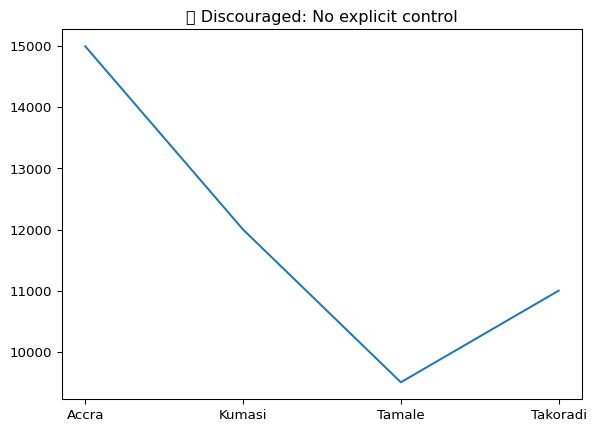

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Sample Data: Tech Salaries in Ghana (Synthetic)
cities = ['Accra', 'Kumasi', 'Tamale', 'Takoradi']
salaries = [15000, 12000, 9500, 11000]

plt.plot(cities, salaries)
plt.title("❌ Discouraged: No explicit control")
plt.show()

**Why we avoid it:** It becomes “Spaghetti code” quickly. If you have
two different figures, Matplotlib loses track of which one is current,
leading to bugs.

### ✅ The Explicit Interface (The OOP Way) - Recommended

This is the **Professional Standard.** You explicitly create “Figure”
and “Axes” objects.

C:\Users\User1\Documents\GIZ_GhanaAI_Training_Materials\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.


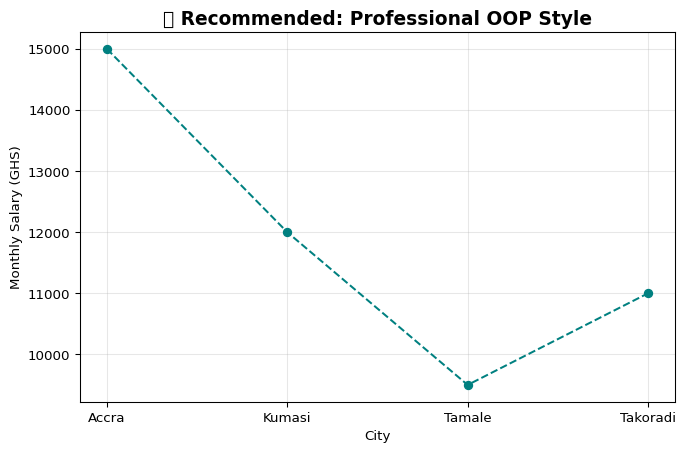

In [2]:
# Create the figure (the canvas) and the axes (the drawing area)
fig, ax = plt.subplots(figsize=(8, 5))

# Use the AXES object to draw
ax.plot(cities, salaries, marker='o', linestyle='--', color='teal')

# Set properties on the AXES object
ax.set_title("✅ Recommended: Professional OOP Style", fontsize=14, fontweight='bold')
ax.set_xlabel("City")
ax.set_ylabel("Monthly Salary (GHS)")
ax.grid(True, alpha=0.3)

plt.show()

------------------------------------------------------------------------

# 3. Why Explicit (OOP) is the AI Standard

As an AI Engineer, you aren’t just making one plot. You are making
**dashboards**, **sub-plots**, and **integrated pipelines**.

| Feature | Implicit (`plt.plot`) | Explicit (`ax.plot`) |
|:-----------------------|:-----------------------|:-----------------------|
| **Control** | Global (hard to manage multiple plots) | Local (Target specific axes) |
| **Complexity** | Messy and hard to debug | Scales to complex multi-paneled figures |
| **Production** | Almost impossible to test/modularize | Easy to pass `ax` objects into functions |
| **Conclusion** | **DO NOT USE** | **USE ALWAYS** |

------------------------------------------------------------------------

# 4. Our Recommended Workflow: Pandas `.plot()` + Explicit Injection

This is the most efficient way to work. You use the convenience of
Pandas but the power of OOP by **injecting** theAxes object.

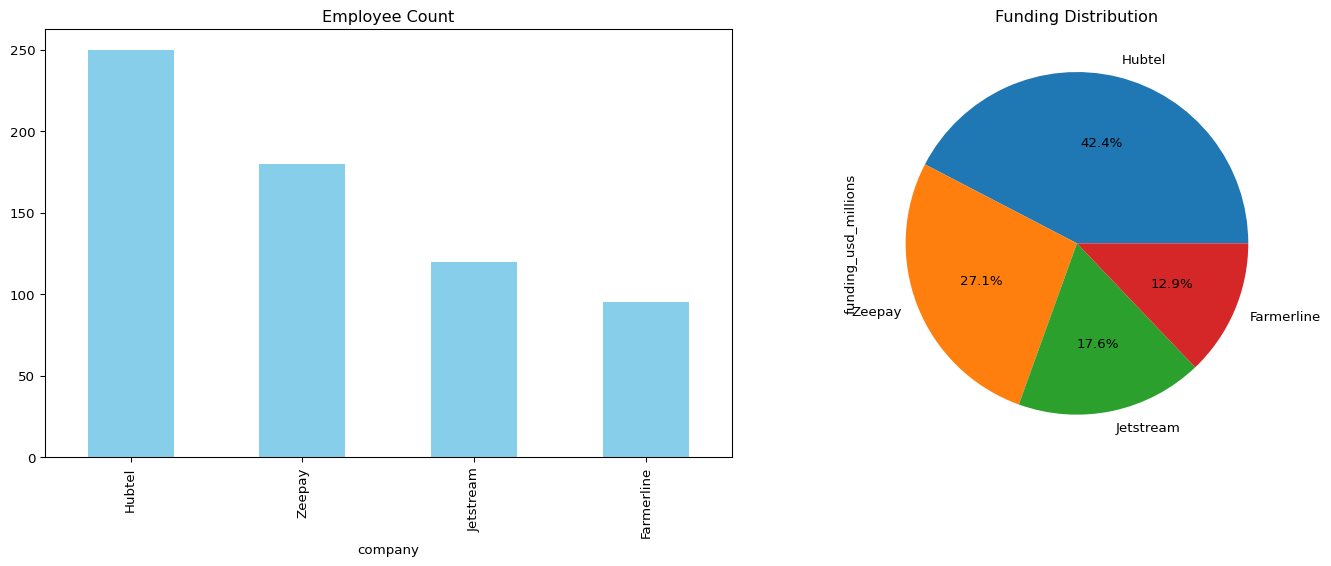

In [3]:
# Re-using our startup data
startup_data = pd.DataFrame({
    "company": ["Hubtel", "Zeepay", "Jetstream", "Farmerline"],
    "employees": [250, 180, 120, 95],
    "funding_usd_millions": [12.5, 8.0, 5.2, 3.8]
})

# 1. Create the OOP structure (the empty grid)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 2. Inject ax into Pandas plotting
startup_data.plot(
    kind='bar', 
    x='company', 
    y='employees', 
    ax=ax1, # <--- THE "INJECTION" STEP
    color='skyblue',
    legend=False
)
ax1.set_title("Employee Count")

startup_data.plot(
    kind='pie', 
    labels=startup_data['company'], 
    y='funding_usd_millions', 
    ax=ax2, # <--- THE "INJECTION" STEP
    autopct='%1.1f%%',
    legend=False
)
ax2.set_title("Funding Distribution")

plt.tight_layout()
plt.show()

------------------------------------------------------------------------

# 5. Seaborn: Statistical Beauty & Integration

Seaborn is built on top of Matplotlib. It focuses on **what** you want
to plot rather than **how** to draw every line. Its greatest strength is
handling DataFrames natively and making complex statistical
visualizations with single lines of code.

### 5.1 The Seaborn Integration Pattern

To use Seaborn in a professional (OOP) workflow, you create your `ax`
object first, then pass it to the Seaborn function.

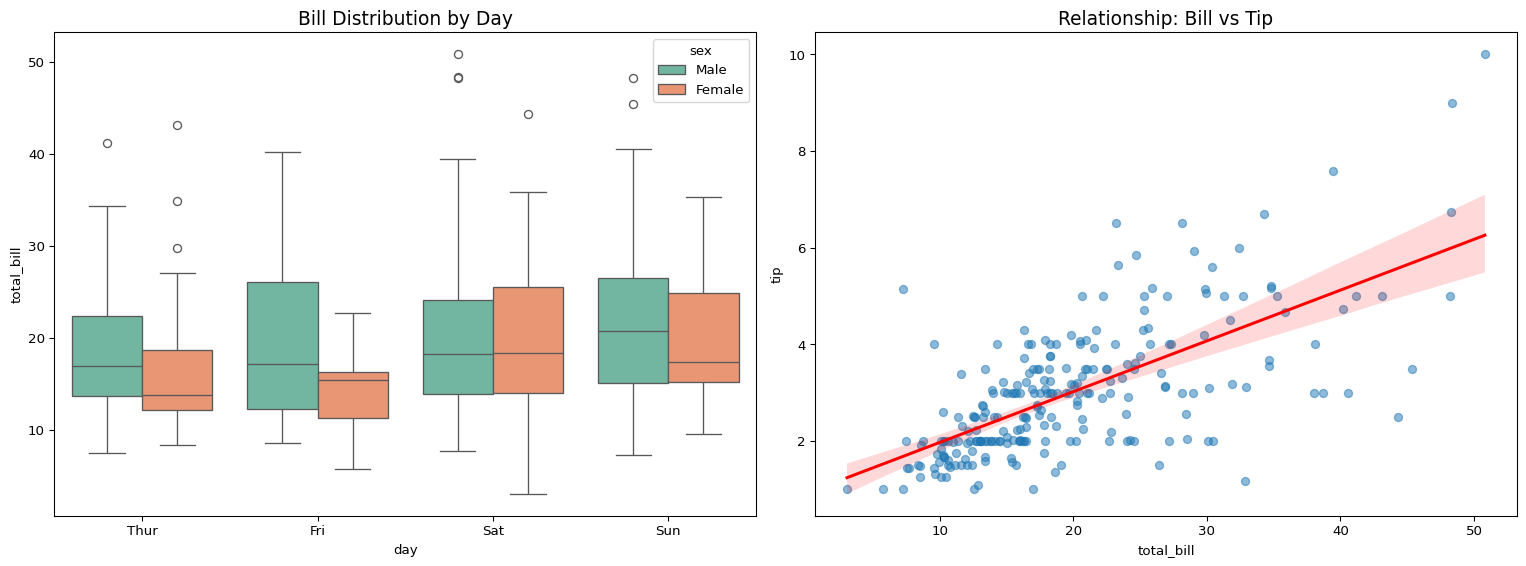

In [4]:
import seaborn as sns

# Load a classic dataset
tips = sns.load_dataset("tips")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Boxplot (Distribution analysis)
sns.boxplot(
    data=tips, 
    x='day', 
    y='total_bill', 
    hue='sex', 
    palette='Set2', 
    ax=ax1 # <--- THE KEY: PASSING THE AXES
)
ax1.set_title("Bill Distribution by Day", fontsize=14)

# 2. Regplot (Relationship analysis)
sns.regplot(
    data=tips,
    x='total_bill',
    y='tip',
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'},
    ax=ax2 # <--- THE KEY: PASSING THE AXES
)
ax2.set_title("Relationship: Bill vs Tip", fontsize=14)

plt.tight_layout()
plt.show()

### 5.2 Heatmaps for Feature Correlation

In AI Engineering, you will constantly use **Heatmaps** to check for
“Multicollinearity” (when features are too similar).

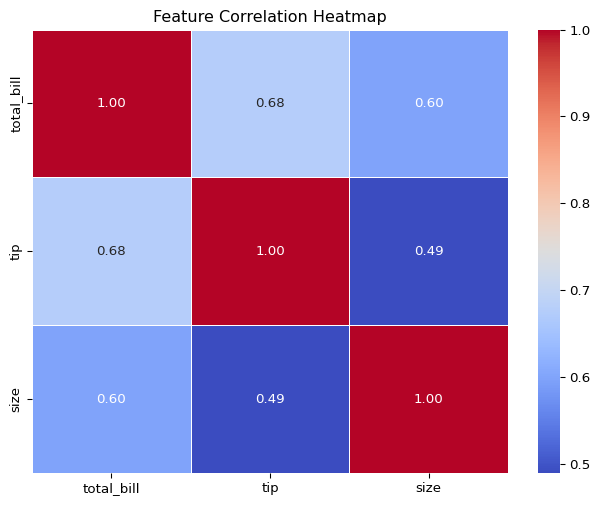

In [5]:
# Create a correlation matrix of numeric columns
corr_matrix = tips.select_dtypes(include=[np.number]).corr()

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f",
    linewidths=0.5,
    ax=ax # <--- THE KEY: PASSING THE AXES
)

ax.set_title("Feature Correlation Heatmap")
plt.show()

> **Why Seaborn + OOP is the “Gold Standard”**
>
> Seaborn handles the complex math (like regression lines and density
> estimates), while Matplotlib’s `ax` gives you surgical control over
> titles, labels, and layout. This combination is what you see in
> top-tier AI research papers.

------------------------------------------------------------------------

# 6. Other Plotting Powerhouses

While we focus on Matplotlib/Seaborn, keep these in your toolkit:

1.  **Plotly Express**: The favorite for interactive web apps
    (Dashboards).
2.  **Altair**: Declarative plotting (similar to the “Grammar of
    Graphics” in R’s ggplot2).
3.  **Bokeh**: Best for high-performance interactive plots on huge
    datasets.

------------------------------------------------------------------------

# 7. Practice Challenge: Ghana Tourism Analysis

Given the following tourism data, create a professional figure with
**two subplots** (side-by-side): 1. A line plot showing tourists over
time. 2. A bar chart showing revenue by region.

*Requirement: Use the Explicit (OOP) `fig, ax` interface.*

In [6]:
tourism_years = [2018, 2019, 2020, 2021, 2022]
tourists_k = [950, 1130, 350, 620, 980] # Drop due to 2020

regional_revenue = pd.DataFrame({
    "region": ["Greater Accra", "Ashanti", "Central", "Volta"],
    "revenue_m": [120, 85, 95, 45]
})

# Your Solution Here:
# fig, (ax1, ax2) = ...

------------------------------------------------------------------------

# 8. What’s Next?

We’ve turned data into insights. But what if the data is messy? In the
final module, we tackle **Data Integrity**.

**Next Module: [Notebook 3: The Tidy Data
Revolution](file:///home/siseng_ai/Documents/Ubuntu_2404/Speedykom/Ghana_AI/TrainingMaterials/intro_pandas3.qmd)**

-   Messy vs Tidy data
-   Melt, Pivot, and Reshaping
-   Building professional cleaning pipelines